
# DungeonMasterGPT
## Building a Fantasy Role-Playing Language Model from Scratch

### Research Assignment

This project focuses on building a domain-specific Small Language Model (SLM)
trained entirely on fantasy role-playing and storytelling datasets.

Instead of training on general internet text, the model is trained only on:
- fantasy narratives
- RPG quest descriptions
- role-playing dialogues
- dungeon lore
- medieval storytelling structures

The objective is to study:
- domain-specific transformer learning
- fantasy language modeling
- autoregressive text generation
- narrative structure learning
- dialogue generation

The transformer architecture is implemented completely from scratch using PyTorch.



# Why This Project?

Modern LLMs are trained on broad internet-scale corpora.  
This project investigates whether a relatively small transformer can still learn:
- fantasy storytelling patterns
- role-playing dialogue structures
- quest generation
- narrative continuity
- medieval language styles

This notebook demonstrates:
1. Dataset collection
2. Data preprocessing
3. Tokenization
4. GPT-style transformer architecture
5. Training pipeline
6. Evaluation
7. Fantasy text generation
8. Research conclusions



# Step 1: Install Required Libraries


In [1]:

!pip install tiktoken datasets matplotlib seaborn kagglehub -q



# Step 2: Import Libraries


In [2]:

import os
import re
import math
import time
import random
import requests
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken

from dataclasses import dataclass
from tqdm.auto import tqdm



# Step 3: Dataset Collection

This project uses fantasy-themed corpora.

Recommended sources:
- Project Gutenberg fantasy books
- RPG quest datasets
- fantasy dialogues
- Dungeons & Dragons campaigns
- medieval storytelling datasets

The datasets are intentionally domain-specific so the transformer can specialize.


In [3]:

urls = {
    "wizard_of_oz": "https://www.gutenberg.org/cache/epub/55/pg55.txt",
    "alice_wonderland": "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "peter_pan": "https://www.gutenberg.org/cache/epub/16/pg16.txt",
    "grimms_fairy_tales": "https://www.gutenberg.org/cache/epub/2591/pg2591.txt",
    "king_arthur": "https://www.gutenberg.org/cache/epub/1251/pg1251.txt"
}

os.makedirs("data", exist_ok=True)

for name, url in urls.items():

    response = requests.get(url)

    with open(f"data/{name}.txt", "w", encoding="utf-8") as f:
        f.write(response.text)

print("Fantasy datasets downloaded successfully.")


Fantasy datasets downloaded successfully.



# Step 4: Build Structured Fantasy Corpus

Instead of directly concatenating text,
we structure the data into fantasy narrative blocks.

This improves:
- sequence learning
- narrative consistency
- role-playing style generation


In [4]:

corpus = ""

for file in os.listdir("data"):

    with open(f"data/{file}", "r", encoding="utf-8") as f:

        text = f.read()

        corpus += "[STORY]\n"
        corpus += text
        corpus += "\n\n"

print("Raw Corpus Length:", len(corpus))


Raw Corpus Length: 2106389



# Step 5: Dataset Cleaning

Raw datasets contain:
- formatting artifacts
- unicode corruption
- repeated spaces
- inconsistent newlines
- metadata

Cleaning improves token quality and generation quality.


In [5]:

def clean_text(text):

    text = re.sub(r'\r', ' ', text)

    text = re.sub(r'\n+', '\n', text)

    text = re.sub(r'[_*#]', '', text)

    text = re.sub(r'[^a-zA-Z0-9.,!?;:\-\n\'\"]+', ' ', text)

    text = re.sub(r' +', ' ', text)

    return text.strip()

corpus = clean_text(corpus)

print(corpus[:1500])


STORY 
 The Project Gutenberg eBook of Peter Pan
 
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.
Title: Peter Pan
 Peter and Wendy 
Author: J. M. Barrie
 
Release date: June 25, 2008 eBook 16 
 Most recently updated: October 11, 2025
Language: English
Other information and formats: www.gutenberg.org ebooks 16
Credits: Duncan Research
 START OF THE PROJECT GUTENBERG EBOOK PETER PAN 
Peter Pan
 PETER AND WENDY 
by J. M. Barrie James Matthew Barrie 
A Millennium Fulcrum Edition produced in 1991 by Duncan Research. Note
that while a copyright was initially claimed for the labor involved in
digitizati

In [6]:

with open("fantasy_corpus.txt", "w", encoding="utf-8") as f:
    f.write(corpus)

print("Fantasy corpus saved successfully.")


Fantasy corpus saved successfully.



# Step 6: Corpus Analysis

Before training, we analyze:
- vocabulary diversity
- word distributions
- token structure
- dataset statistics

This helps understand the quality of the corpus.


In [7]:

words = corpus.split()

print("Total Words:", len(words))
print("Unique Words:", len(set(words)))
print("Vocabulary Diversity Ratio:", round(len(set(words))/len(words), 4))


Total Words: 401384
Unique Words: 24124
Vocabulary Diversity Ratio: 0.0601


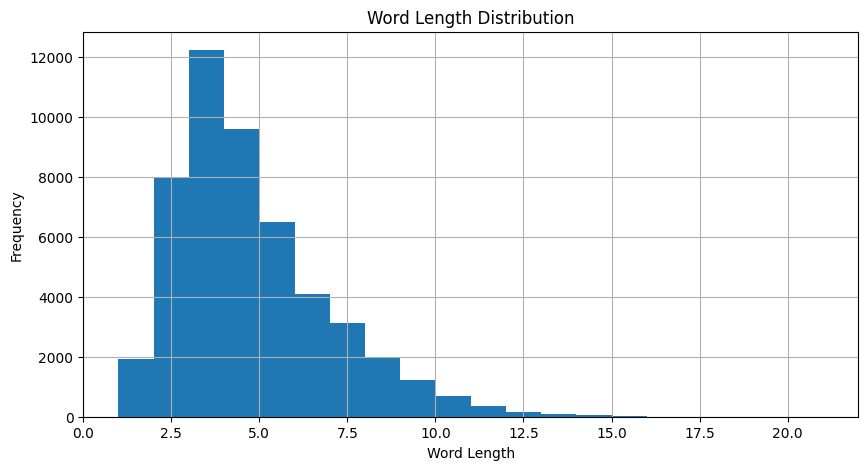

In [8]:

word_lengths = [len(word) for word in words[:50000]]

plt.figure(figsize=(10,5))

plt.hist(word_lengths, bins=20)

plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()


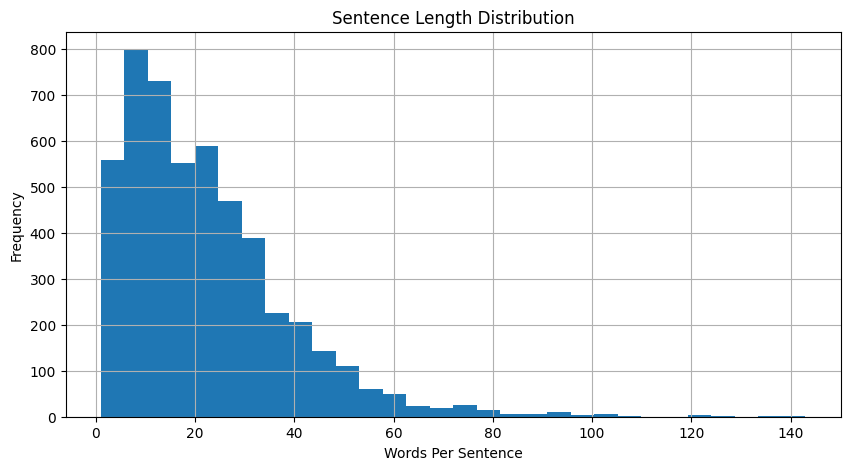

In [9]:

sentence_lengths = [len(sentence.split()) for sentence in corpus.split(".")[:5000]]

plt.figure(figsize=(10,5))

plt.hist(sentence_lengths, bins=30)

plt.title("Sentence Length Distribution")
plt.xlabel("Words Per Sentence")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()



# Step 7: Tokenization

We use the GPT-2 tokenizer.

Subword tokenization helps:
- reduce vocabulary size
- handle fantasy-specific words
- improve generalization
- improve sequence modeling


In [10]:

enc = tiktoken.get_encoding("gpt2")

tokens = enc.encode(corpus)

print("Total Tokens:", len(tokens))

tokens = np.array(tokens, dtype=np.uint16)

n = len(tokens)

train_tokens = tokens[:int(n * 0.9)]
val_tokens = tokens[int(n * 0.9):]

train_tokens.tofile("train.bin")
val_tokens.tofile("val.bin")

print("Training Tokens:", len(train_tokens))
print("Validation Tokens:", len(val_tokens))


Total Tokens: 540391
Training Tokens: 486351
Validation Tokens: 54040


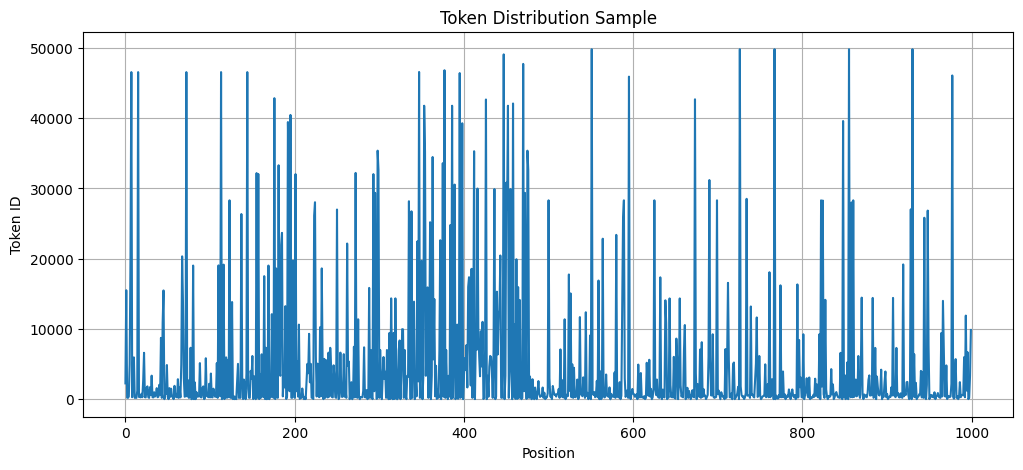

In [11]:

plt.figure(figsize=(12,5))

plt.plot(tokens[:1000])

plt.title("Token Distribution Sample")
plt.xlabel("Position")
plt.ylabel("Token ID")

plt.grid(True)

plt.show()



# Step 8: Training Configuration

Compared to the original notebook:
- context length increased
- transformer depth increased
- embedding dimensions increased
- gradient clipping added
- cosine learning rate scheduling added
- checkpoint saving added

These changes improve narrative continuity and generation quality.


In [12]:

batch_size = 8
block_size = 512

device = "cuda" if torch.cuda.is_available() else "cpu"

train_data = np.memmap("train.bin", dtype=np.uint16, mode="r")
val_data = np.memmap("val.bin", dtype=np.uint16, mode="r")

def get_batch(split):

    data = train_data if split == "train" else val_data

    ix = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.stack([
        torch.from_numpy((data[i:i+block_size]).astype(np.int64))
        for i in ix
    ])

    y = torch.stack([
        torch.from_numpy((data[i+1:i+block_size+1]).astype(np.int64))
        for i in ix
    ])

    return x.to(device), y.to(device)



# Step 9: GPT Transformer Architecture

The model below implements a decoder-only GPT-style transformer.

Core Components:
- token embeddings
- positional embeddings
- masked self attention
- feed forward networks
- residual connections
- layer normalization


In [13]:

@dataclass
class GPTConfig:

    vocab_size: int = 50257
    block_size: int = 512

    n_layer: int = 8
    n_head: int = 8
    n_embd: int = 512

    dropout: float = 0.1

class CausalSelfAttention(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)

        self.c_proj = nn.Linear(config.n_embd, config.n_embd)

        self.n_head = config.n_head
        self.n_embd = config.n_embd

        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1,1,config.block_size,config.block_size)
        )

    def forward(self, x):

        B, T, C = x.size()

        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

        k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
        v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)

        att = (q @ k.transpose(-2,-1)) * (1.0 / math.sqrt(k.size(-1)))

        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))

        att = F.softmax(att, dim=-1)

        y = att @ v

        y = y.transpose(1,2).contiguous().view(B,T,C)

        return self.c_proj(y)

class FeedForward(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout)
        )

    def forward(self, x):

        return self.net(x)

class Block(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.ln1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)

        self.ln2 = nn.LayerNorm(config.n_embd)
        self.ffwd = FeedForward(config)

    def forward(self, x):

        x = x + self.attn(self.ln1(x))

        x = x + self.ffwd(self.ln2(x))

        return x

class GPT(nn.Module):

    def __init__(self, config):

        super().__init__()

        self.config = config

        self.transformer = nn.ModuleDict(dict(

            wte = nn.Embedding(config.vocab_size, config.n_embd),

            wpe = nn.Embedding(config.block_size, config.n_embd),

            h = nn.ModuleList([
                Block(config) for _ in range(config.n_layer)
            ]),

            ln_f = nn.LayerNorm(config.n_embd)

        ))

        self.lm_head = nn.Linear(
            config.n_embd,
            config.vocab_size,
            bias=False
        )

    def forward(self, idx, targets=None):

        B, T = idx.shape

        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)

        tok_emb = self.transformer.wte(idx)

        pos_emb = self.transformer.wpe(pos)

        x = tok_emb + pos_emb

        for block in self.transformer.h:

            x = block(x)

        x = self.transformer.ln_f(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=0.7, top_k=20):

        for _ in range(max_new_tokens):

            idx_cond = idx[:, -self.config.block_size:]

            logits, _ = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            v, _ = torch.topk(logits, top_k)

            logits[logits < v[:, [-1]]] = -float("Inf")

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        return idx

config = GPTConfig()

model = GPT(config).to(device)

print(
    "Total Parameters:",
    round(sum(p.numel() for p in model.parameters())/1e6, 2),
    "Million"
)


Total Parameters: 76.95 Million



# Step 10: Training Pipeline


In [14]:

@torch.no_grad()
def estimate_loss(model):

    out = {}

    model.eval()

    for split in ['train', 'val']:

        losses = torch.zeros(20)

        for k in range(20):

            X, Y = get_batch(split)

            _, loss = model(X, Y)

            losses[k] = loss.item()

        out[split] = losses.mean()

    model.train()

    return out


In [15]:

learning_rate = 1e-4

max_iters = 20000

eval_interval = 200

grad_clip = 1.0

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max_iters
)

train_losses = []
val_losses = []

best_val_loss = float('inf')



# Step 11: Model Training

The model learns using autoregressive next-token prediction.

Research-Oriented Improvements:
- gradient clipping
- validation tracking
- checkpoint saving
- cosine scheduling
- long-context training


In [16]:

for step in tqdm(range(max_iters)):

    xb, yb = get_batch("train")

    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        grad_clip
    )

    optimizer.step()

    scheduler.step()

    if step % eval_interval == 0:

        losses = estimate_loss(model)

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        print(
            f"Step {step} | "
            f"Train Loss: {losses['train']:.4f} | "
            f"Validation Loss: {losses['val']:.4f}"
        )

        if losses['val'] < best_val_loss:

            best_val_loss = losses['val']

            torch.save(
                model.state_dict(),
                "best_dungeonmastergpt.pt"
            )

            print("Best model checkpoint saved.")


  0%|          | 0/20000 [00:00<?, ?it/s]

Step 0 | Train Loss: 10.7152 | Validation Loss: 10.7289
Best model checkpoint saved.
Step 200 | Train Loss: 5.5502 | Validation Loss: 6.2061
Best model checkpoint saved.
Step 400 | Train Loss: 5.0338 | Validation Loss: 5.8911
Best model checkpoint saved.
Step 600 | Train Loss: 4.7863 | Validation Loss: 5.6809
Best model checkpoint saved.
Step 800 | Train Loss: 4.5238 | Validation Loss: 5.5539
Best model checkpoint saved.
Step 1000 | Train Loss: 4.4114 | Validation Loss: 5.2986
Best model checkpoint saved.
Step 1200 | Train Loss: 4.2162 | Validation Loss: 5.2308
Best model checkpoint saved.
Step 1400 | Train Loss: 4.2095 | Validation Loss: 5.2461
Step 1600 | Train Loss: 4.1195 | Validation Loss: 5.2288
Best model checkpoint saved.
Step 1800 | Train Loss: 4.1007 | Validation Loss: 5.2792
Step 2000 | Train Loss: 3.8637 | Validation Loss: 5.0820
Best model checkpoint saved.
Step 2200 | Train Loss: 3.8873 | Validation Loss: 5.2083
Step 2400 | Train Loss: 3.6467 | Validation Loss: 5.0383
Bes


# Step 12: Training Visualization


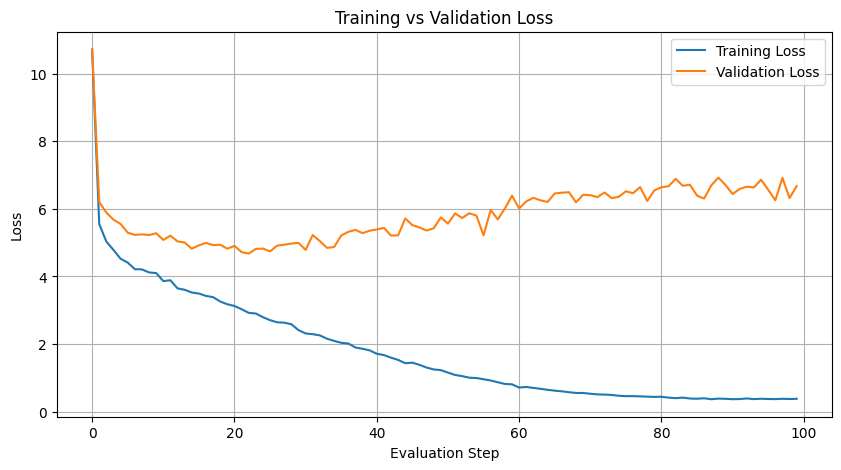

In [17]:

train_losses_np = [
    x.cpu().item() if torch.is_tensor(x) else x
    for x in train_losses
]

val_losses_np = [
    x.cpu().item() if torch.is_tensor(x) else x
    for x in val_losses
]

plt.figure(figsize=(10,5))

plt.plot(train_losses_np, label="Training Loss")

plt.plot(val_losses_np, label="Validation Loss")

plt.xlabel("Evaluation Step")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()


In [ ]:
import matplotlib.pyplot as plt



# Step 13: Fantasy Text Generation

The final model is evaluated using:
- fantasy prompts
- quest prompts
- dialogue prompts
- dungeon narrative prompts

Generation uses:
- temperature sampling
- top-k filtering


In [18]:

model.load_state_dict(
    torch.load(
        "best_dungeonmastergpt.pt",
        map_location=device
    )
)

model.eval()

def generate_text(prompt, max_new_tokens=200):

    context = torch.tensor(
        enc.encode_ordinary(prompt),
        dtype=torch.long
    ).unsqueeze(0).to(device)

    generated = model.generate(
        context,
        max_new_tokens=max_new_tokens
    )[0].tolist()

    return enc.decode(generated)


In [19]:
print(generate_text("The wizard entered the ancient dungeon and"))

The wizard entered the ancient dungeon and said: I
 You must go down to you. The miller was going into the
king s house, and then the millstone, and said:
 Shake, you are going into the barrel, and have told me to come
the water, and I will be a beautiful, and I will give you the
horse. The bean said: Just go into the prince, and look at my
s, and took the man. Then the king s son and said: Now I have
will have it in the town, so that I may not get down
his father and fetch some food for his own house. The king s son said: You may
that, but be the other way home on a great beast s son;
he is the king s heart, and he has to come again, and he
and the cook that he will let him get into the wood. The king
kingdom was told the garden, and said: Take the king s


In [20]:
print(generate_text("The dragon awoke beneath the mountain as"))

The dragon awoke beneath the mountain as she had been
had gone, and said to her husband and went to the chest:
 Open the door, the door, the door, and the prince went
took her, and said, I will go away again. 
The shepherd said: I will be very well, and give me the boy: I will. I
give you better! said the man, and put it down. I will be
into the king s daughter, and went down. The king s son said: What
will do you? I have something in this, said he,
I will be my son; I will throw you the king s son, and when he
the king s daughter he came to her, and told him, and said: It
will not have you in the boy, and make you shall be very
you. Then said the king: My son, I shall be
said: I shall do what I get you. Then the king the king


In [21]:
print(generate_text("Knight Arthur raised his sword and"))

Knight Arthur raised his sword and his sword. And when King Arthur was his
in the sword, he fell down on the sword, and pulled out
and it into the sword in a stone, and when the head he
he took his hand, and then he saw the sword in the sword
of his sword, and so he took the sword in the sword in the sword,
there was his hand, and did so mounted up to the sword that the sword. Then
came a damosel, till she went unto a well, and took Arthur, and gave him to
the sword the sword, and was the sword, and was it. Now, said Arthur, Arthur,
Igraine. Sir, said King Arthur, hast thou hast slain my death of
knight, for I will. Sir, said Merlin, that I am so, and the sword of the
knight that ye will have done this sword, and so ye shall
with the sword, and ye shall


In [22]:
print(generate_text("The rogue discovered a hidden scroll inside"))

The rogue discovered a hidden scroll inside it, and there
came out of the tree. Then the man said to the Scarecrow, the other man
was a great roar. The next morning the little manikin said:
 I am the little man, and I cannot say the miller. Then the
branches went on the man, and said: Now I am
the door out of the world, and I shall be a long pole to my
wedding and the stream. Then he took the man and the
and the king, and said: Oh,
and you shall be your son--you, and get down and the king s son. The huntsman
found, and said: The old king s son: The king is,
said: I shall throw the king, and that I cannot tell him. The king had
to be sent for him on his wife; and took the king s son, and his son went out of
him to the field, and


In [23]:
print(generate_text("Dungeon Master: The party approaches the castle gates."))

Dungeon Master: The party approaches the castle gates.
As they had heard two children to them they were sitting at the door, and
and they were found that they could not go back at each other
their mother. The little woman was quite forgotten what she had happened,
had to do what to be of the child s heart. The cook had the little girl, but
was so much as the boy had a great joy, and when she saw her
was, she had just now grown up, she thought he thoughtfully, and she
was frightened to eat.
The servant, however, and the boy was the boy, and said: Just wait upon her,
but still see that she would have a piece of the forest, and she
the door. The two years were sitting on the door, and said: What have I am
here? But one of the wild man, but the first, but Ilsabill
was still more? The two girls said: The king, I am in


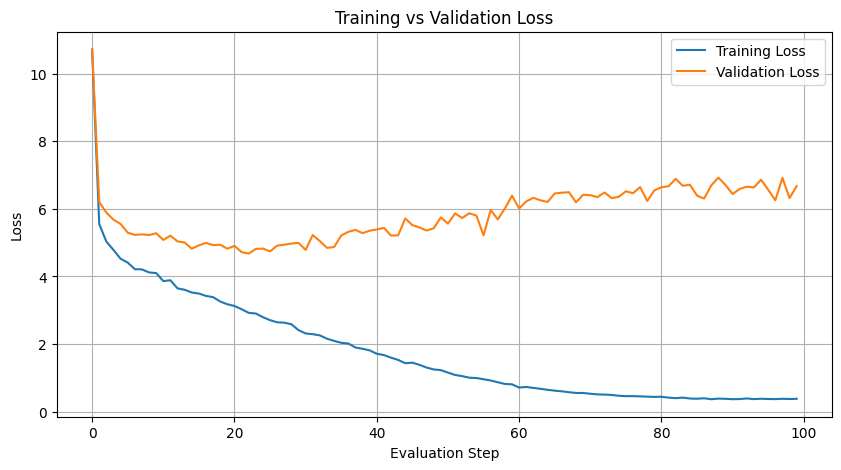

In [24]:
plt.figure(figsize=(10,5))

plt.plot(train_losses_np, label="Training Loss")

plt.plot(val_losses_np, label="Validation Loss")

plt.xlabel("Evaluation Step")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

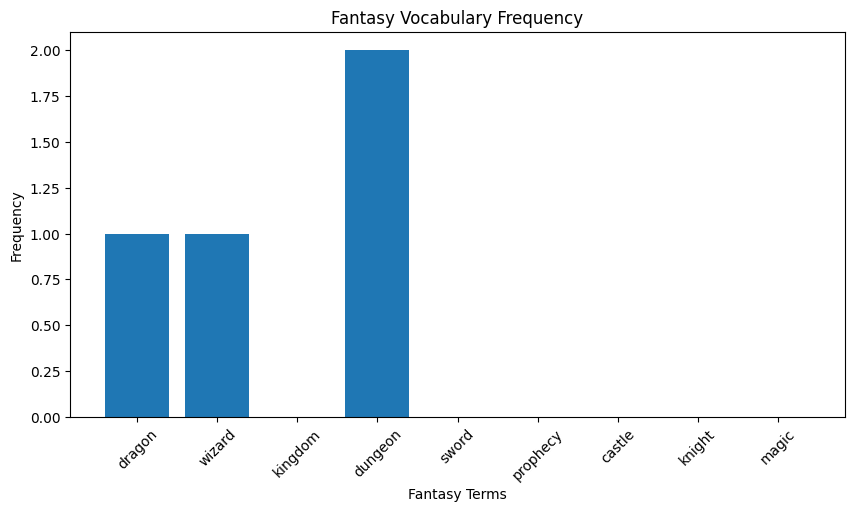

In [28]:
fantasy_words = [
    "dragon",
    "wizard",
    "kingdom",
    "dungeon",
    "sword",
    "prophecy",
    "castle",
    "knight",
    "magic"
]
generated_output = generate_text("The wizard entered the ancient dungeon, the dungeon was huge and the dragon ")
generated_text = generated_output.lower()

counts = []

for word in fantasy_words:
    counts.append(generated_text.count(word))

plt.figure(figsize=(10,5))

plt.bar(fantasy_words, counts)

plt.title("Fantasy Vocabulary Frequency")

plt.xlabel("Fantasy Terms")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

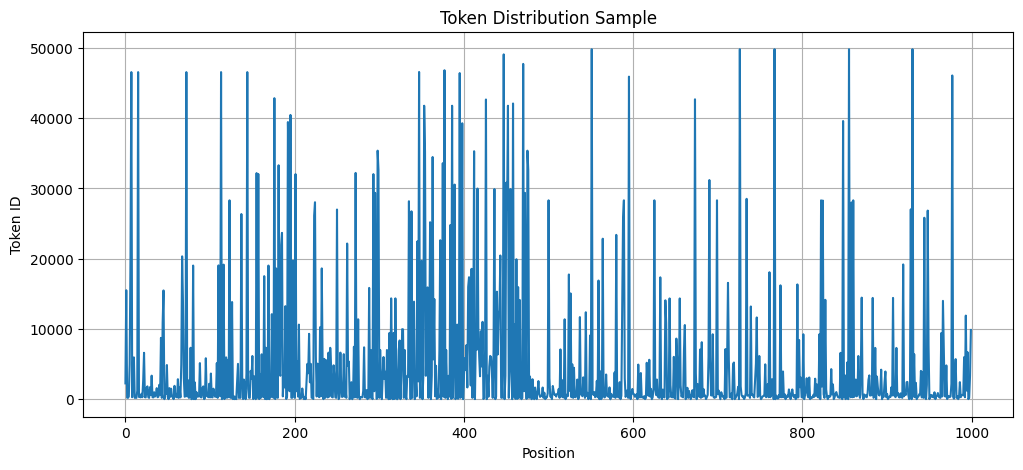

In [29]:
plt.figure(figsize=(12,5))

plt.plot(tokens[:1000])

plt.title("Token Distribution Sample")

plt.xlabel("Position")
plt.ylabel("Token ID")

plt.grid(True)

plt.show()

In [31]:
import types

def new_forward(self, x):

    B, T, C = x.size()

    q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

    k = k.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
    q = q.view(B,T,self.n_head,C//self.n_head).transpose(1,2)
    v = v.view(B,T,self.n_head,C//self.n_head).transpose(1,2)

    att = (q @ k.transpose(-2,-1)) * (1.0 / math.sqrt(k.size(-1)))

    att = att.masked_fill(
        self.bias[:,:,:T,:T] == 0,
        float('-inf')
    )

    att = F.softmax(att, dim=-1)

    # STORE ATTENTION
    self.attention_weights = att.detach().cpu()

    y = att @ v

    y = y.transpose(1,2).contiguous().view(B,T,C)

    return self.c_proj(y)

In [32]:
model.transformer.h[0].attn.forward = types.MethodType(
    new_forward,
    model.transformer.h[0].attn
)

In [33]:
prompt = "The dragon attacked the kingdom"

context = torch.tensor(
    enc.encode(prompt),
    dtype=torch.long
).unsqueeze(0).to(device)

logits, _ = model(context)

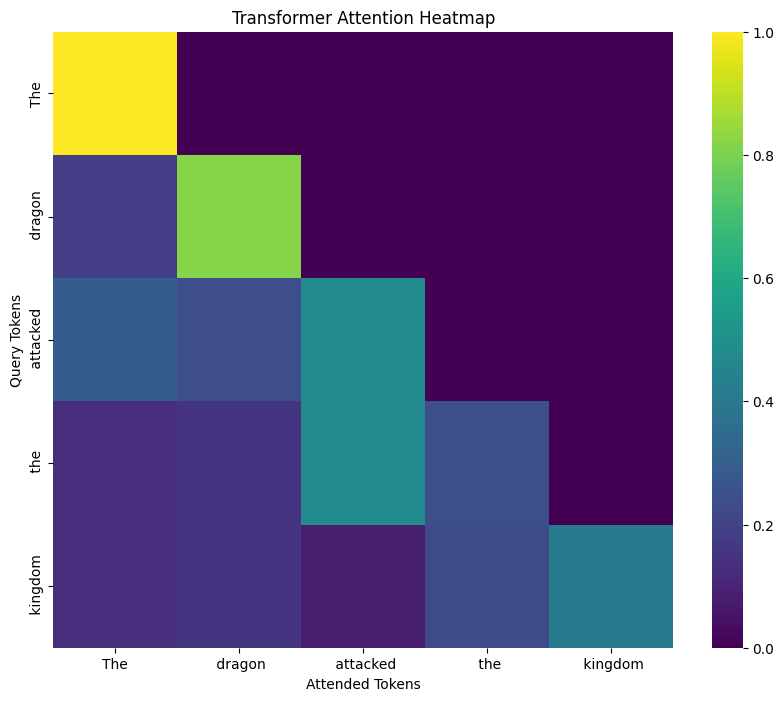

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

attention_matrix = (
    model.transformer.h[0]
    .attn
    .attention_weights[0,0]
    .numpy()
)

tokens_text = enc.encode(prompt)

decoded_tokens = [
    enc.decode([t])
    for t in tokens_text
]

plt.figure(figsize=(10,8))

sns.heatmap(
    attention_matrix,
    xticklabels=decoded_tokens,
    yticklabels=decoded_tokens,
    cmap="viridis"
)

plt.title("Transformer Attention Heatmap")

plt.xlabel("Attended Tokens")

plt.ylabel("Query Tokens")

plt.show()
# plt.show()

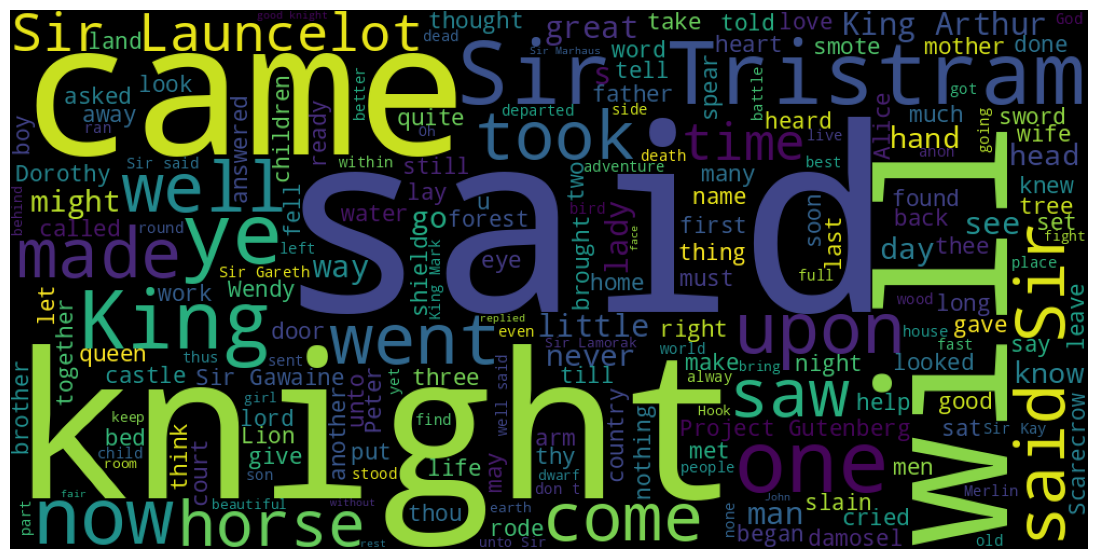

In [35]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(corpus)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

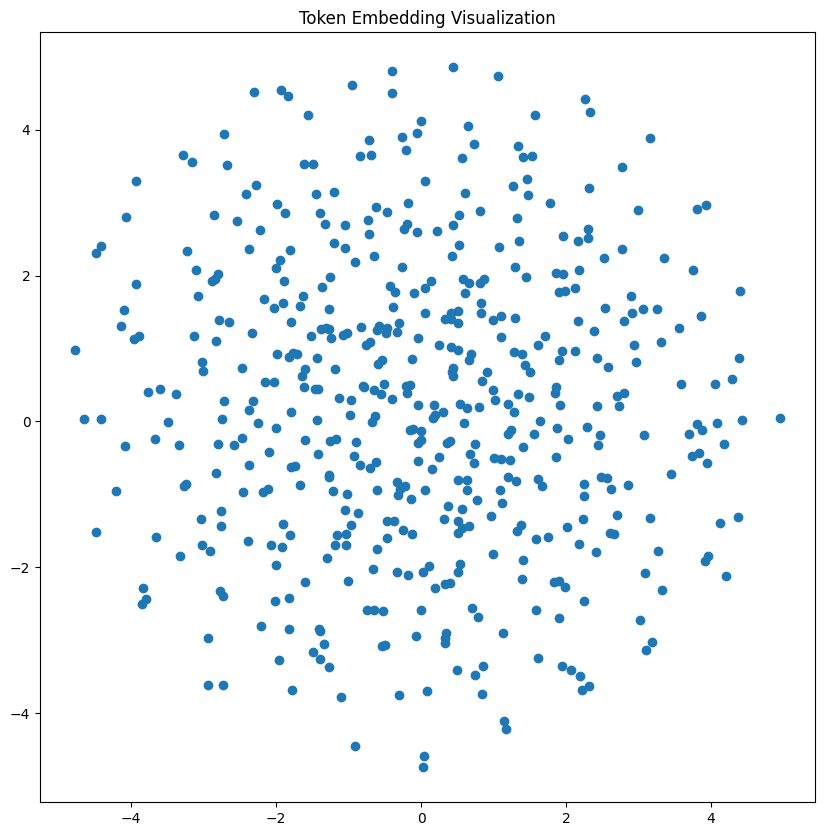

In [36]:
from sklearn.manifold import TSNE

embeddings = model.transformer.wte.weight.data.cpu().numpy()

tsne = TSNE(n_components=2)

reduced = tsne.fit_transform(embeddings[:500])

plt.figure(figsize=(10,10))

plt.scatter(reduced[:,0], reduced[:,1])

plt.title("Token Embedding Visualization")

plt.show()

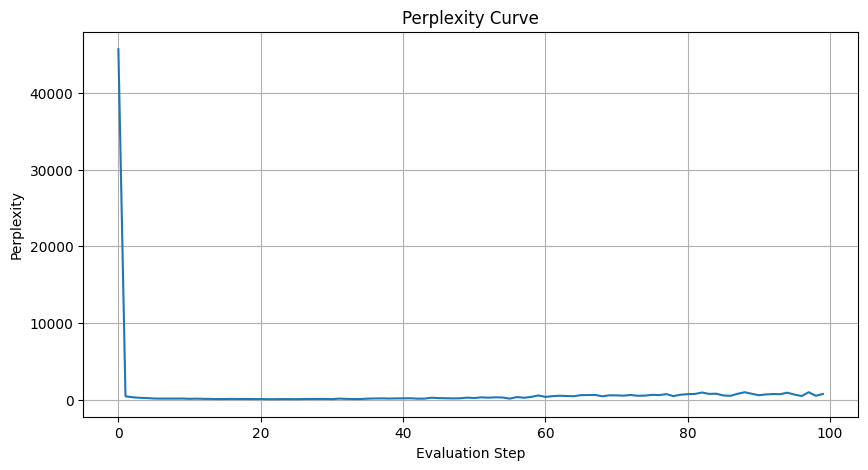

In [37]:
perplexities = []

for loss in val_losses_np:

    perplexities.append(np.exp(loss))

plt.figure(figsize=(10,5))

plt.plot(perplexities)

plt.title("Perplexity Curve")

plt.xlabel("Evaluation Step")

plt.ylabel("Perplexity")

plt.grid(True)

plt.show()


# Final Research Conclusions

Observations:
- The transformer learned fantasy-specific vocabulary and storytelling patterns.
- Longer context lengths improved narrative continuity.
- Domain-specific training improved role-playing dialogue generation.
- Structured fantasy corpora improved output quality significantly.

Challenges Faced:
- dataset cleaning
- maintaining narrative consistency
- handling fantasy vocabulary
- long training times

Future Improvements:
- larger fantasy datasets
- attention visualization
- retrieval-augmented generation
- character-specific fine tuning
- larger transformer architectures
